# HW1 — VSSD на STL-10

**Задача**: классификация изображений STL-10 (10 классов)  
**Модели**: VSSD (`Backbone_VMAMBA2`) vs EfficientNet-B0  

In [ ]:
import subprocess
import os
import sys

if not os.path.exists('VSSD'):
    subprocess.run(['git', 'clone', 'https://github.com/YuHengsss/VSSD.git'], check=True)

sys.path.insert(0, './VSSD/classification')

Cloning into 'VSSD'...


In [ ]:
!pip install causal-conv1d>=1.2.0
!pip install mamba-ssm
!pip install fvcore iopath
!pip install  torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install  timm matplotlib seaborn scikit-learn tqdm pandas

  error: subprocess-exited-with-error
  
  × Building wheel for causal-conv1d (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  ERROR: Failed building wheel for causal-conv1d
ERROR: ERROR: Failed to build installable wheels for some pyproject.toml based projects (causal-conv1d)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 216.4/216.4 kB 8.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a s

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader
from sklearn.metrics import confusion_matrix

from models.mamba2 import Backbone_VMAMBA2
from tqdm.auto import tqdm

mamba_ssm not found


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [ ]:
assert torch.cuda.is_available()
DEVICE = torch.device('cuda')
BATCH_SIZE = 32
EPOCHS = 15
LR = 1e-4
NUM_CLASSES = 10

print(f'device: {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

device: cuda
GPU: Tesla T4


## Данные — STL-10

STL-10: 10 классов, 500 train / 800 test на класс, разрешение 96×96. Ресайзим до 224×224.

In [ ]:
train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

train_ds = torchvision.datasets.STL10('./data', split='train', download=True, transform=train_tf)
val_ds   = torchvision.datasets.STL10('./data', split='test',  download=True, transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

CLASSES = train_ds.classes
print(f'train: {len(train_ds)}  val: {len(val_ds)}')
print('classes:', CLASSES)

100%|██████████| 2.64G/2.64G [04:12<00:00, 10.5MB/s]


train: 5000  val: 8000
classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


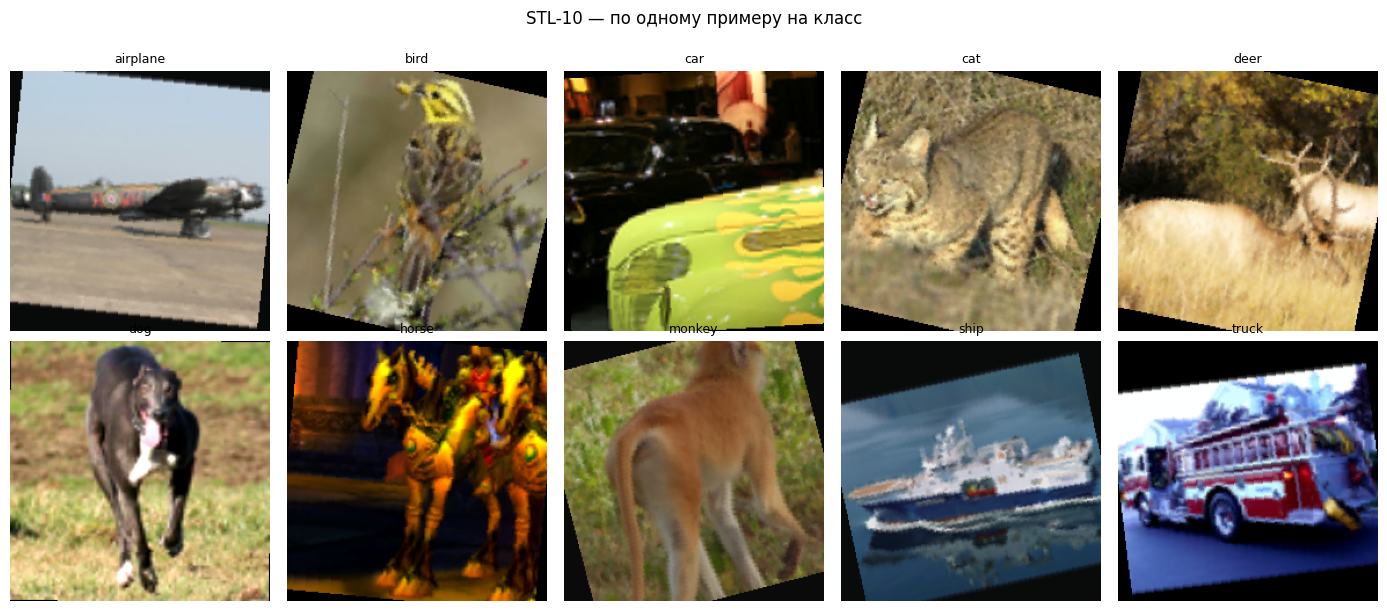

In [ ]:
mean = np.array([0.485, 0.456, 0.406])
std  = np.array([0.229, 0.224, 0.225])

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flat):
    idx = np.where(np.array(train_ds.labels) == i)[0][0]
    img = train_ds[idx][0].permute(1, 2, 0).numpy()
    img = np.clip(img * std + mean, 0, 1)
    ax.imshow(img)
    ax.set_title(CLASSES[i], fontsize=9)
    ax.axis('off')
plt.suptitle('STL-10 — по одному примеру на класс', y=1.01)
plt.tight_layout()
plt.show()

## Модели

In [ ]:
class VSSDClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.backbone = Backbone_VMAMBA2(
            embed_dim=96,
            depths=[2, 2, 6, 2],
            num_heads=[3, 6, 12, 24],
            out_indices=(3,),
            drop_path_rate=0.2,
            mlp_ratio=4.0,
            use_checkpoint=False,
            simple_patch_embed=True,
            simple_downsample=True,
            rmt_downsample=False,
            rmt_patch_embed=False,
            linear_attn_duality=True,
            ssd_positive_da=True,
            exp_da=True,
            rope=True
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(768, 512),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(self.pool(feats[-1]))

In [ ]:
class EffNetBaseline(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
        self.model.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(1280, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [ ]:
def count_params(m):
    return sum(p.numel() for p in m.parameters()) / 1e6

vssd   = VSSDClassifier(NUM_CLASSES).to(DEVICE)
effnet = EffNetBaseline(NUM_CLASSES).to(DEVICE)

print(f'VSSD           : {count_params(vssd):.1f}M params')
print(f'EfficientNet-B0: {count_params(effnet):.1f}M params')

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 200MB/s]

VSSD           : 35.0M params
EfficientNet-B0: 4.0M params


## Обучение

In [ ]:
def run_epoch(model, loader, criterion, optimizer=None):
    training = optimizer is not None
    model.train() if training else model.eval()
    total_loss, correct, n = 0.0, 0, 0

    pbar = tqdm(loader, desc='train' if training else 'val', leave=False)
    with torch.set_grad_enabled(training):
        for imgs, labels in pbar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * imgs.size(0)
            correct    += out.argmax(1).eq(labels).sum().item()
            n          += imgs.size(0)
            pbar.set_postfix(loss=f'{total_loss/n:.4f}', acc=f'{100*correct/n:.1f}%')

    return total_loss / n, 100 * correct / n


def train_model(model, name, epochs=EPOCHS):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=0.05)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    hist = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_acc = 0.0

    for ep in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, criterion, optimizer)
        vl_loss, vl_acc = run_epoch(model, val_loader,   criterion)
        scheduler.step()

        hist['train_loss'].append(tr_loss)
        hist['val_loss'].append(vl_loss)
        hist['train_acc'].append(tr_acc)
        hist['val_acc'].append(vl_acc)

        if vl_acc > best_acc:
            best_acc = vl_acc
            torch.save(model.state_dict(), f'{name}_best.pth')

        print(f'[{name}] ep {ep:02d} | train {tr_acc:.1f}% / {tr_loss:.4f} | val {vl_acc:.1f}% / {vl_loss:.4f}')

    hist['best_acc'] = best_acc
    return hist

In [ ]:
print('=== VSSD ===')
vssd_hist = train_model(vssd, 'vssd')

=== VSSD ===


train:   0%|          | 0/157 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[vssd] ep 01 | train 27.7% / 1.9003 | val 35.0% / 1.6984


train:   0%|          | 0/157 [00:00<?, ?it/s]

...

val:   0%|          | 0/250 [00:00<?, ?it/s]

[vssd] ep 14 | train 84.5% / 0.4554 | val 69.3% / 0.9422


train:   0%|          | 0/157 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[vssd] ep 15 | train 85.4% / 0.4438 | val 69.2% / 0.9442


In [ ]:
print('=== EfficientNet-B0 ===')
eff_hist = train_model(effnet, 'effnet')

=== EfficientNet-B0 ===


train:   0%|          | 0/157 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[effnet] ep 01 | train 77.1% / 1.0110 | val 94.9% / 0.2326


train:   0%|          | 0/157 [00:00<?, ?it/s]

...

val:   0%|          | 0/250 [00:00<?, ?it/s]

[effnet] ep 14 | train 99.3% / 0.0254 | val 97.4% / 0.0827


train:   0%|          | 0/157 [00:00<?, ?it/s]

val:   0%|          | 0/250 [00:00<?, ?it/s]

[effnet] ep 15 | train 99.3% / 0.0275 | val 97.4% / 0.0882


## Результаты

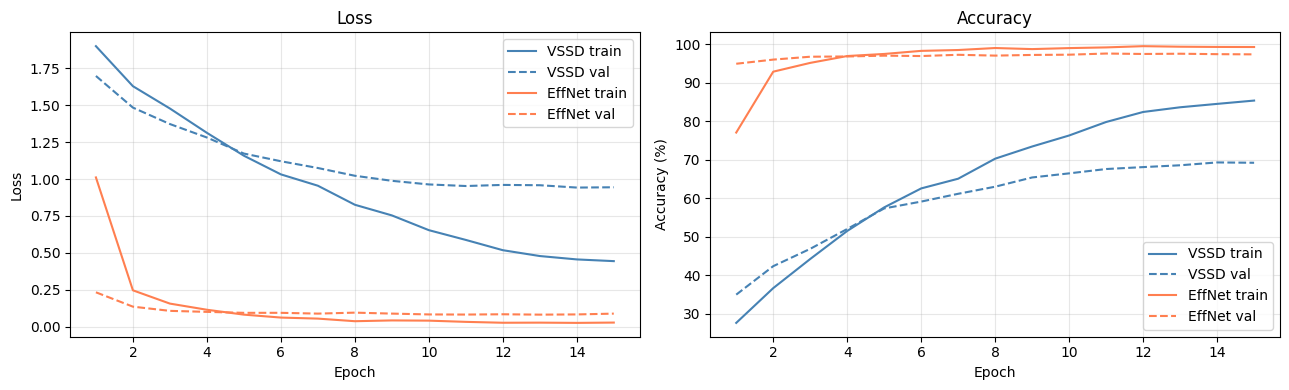

In [ ]:
eps = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(eps, vssd_hist['train_loss'],  color='steelblue', label='VSSD train')
ax1.plot(eps, vssd_hist['val_loss'],   '--', color='steelblue', label='VSSD val')
ax1.plot(eps, eff_hist['train_loss'],   color='coral',     label='EffNet train')
ax1.plot(eps, eff_hist['val_loss'],    '--', color='coral',     label='EffNet val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss'); ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(eps, vssd_hist['train_acc'],  color='steelblue', label='VSSD train')
ax2.plot(eps, vssd_hist['val_acc'],   '--', color='steelblue', label='VSSD val')
ax2.plot(eps, eff_hist['train_acc'],   color='coral',     label='EffNet train')
ax2.plot(eps, eff_hist['val_acc'],    '--', color='coral',     label='EffNet val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy'); ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curves.png', dpi=150)
plt.show()

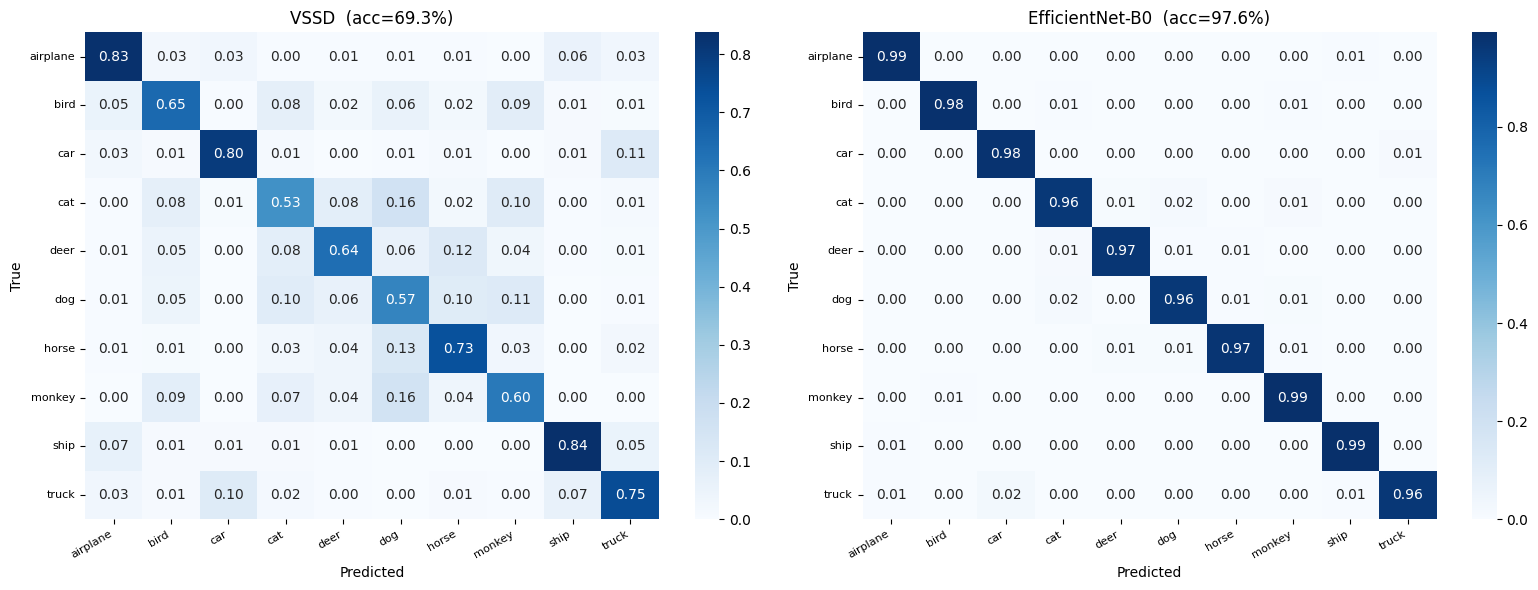

In [ ]:
def get_preds(model, loader, ckpt_path):
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            y_true.extend(labels.numpy())
            y_pred.extend(preds.numpy())
    return np.array(y_true), np.array(y_pred)

yt_v, yp_v = get_preds(vssd,   val_loader, 'vssd_best.pth')
yt_e, yp_e = get_preds(effnet, val_loader, 'effnet_best.pth')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, yt, yp, title in zip(axes,
                              [yt_v, yt_e],
                              [yp_v, yp_e],
                              ['VSSD', 'EfficientNet-B0']):
    cm = confusion_matrix(yt, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES)
    ax.set_title(f'{title}  (acc={100*(yt==yp).mean():.1f}%)')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right', fontsize=8)
    plt.setp(ax.get_yticklabels(), fontsize=8)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150)
plt.show()

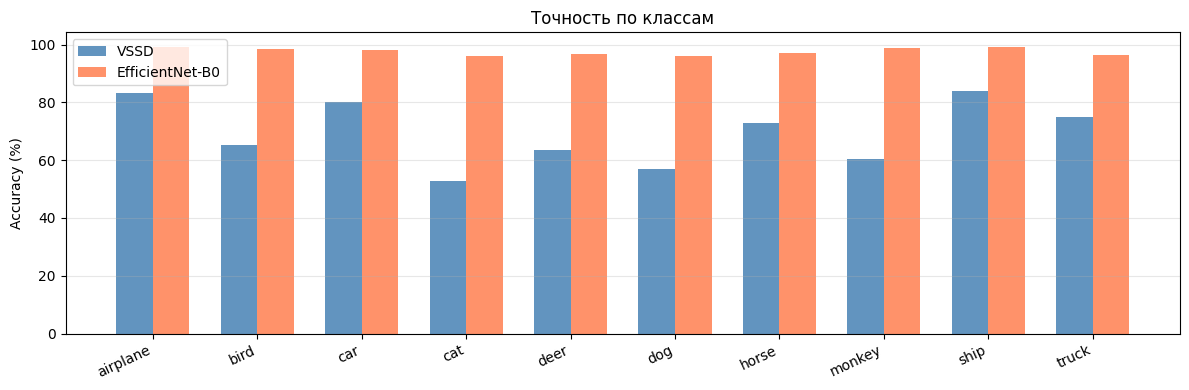

In [ ]:
def per_class_acc(yt, yp):
    return [100 * (yp[yt == c] == c).mean() for c in range(NUM_CLASSES)]

vssd_pc = per_class_acc(yt_v, yp_v)
eff_pc  = per_class_acc(yt_e, yp_e)

x = np.arange(NUM_CLASSES)
w = 0.35
fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - w/2, vssd_pc, w, label='VSSD',           color='steelblue', alpha=0.85)
ax.bar(x + w/2, eff_pc,  w, label='EfficientNet-B0', color='coral',    alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(CLASSES, rotation=25, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Точность по классам')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('per_class_acc.png', dpi=150)
plt.show()

In [ ]:
summary = pd.DataFrame({
    'Model'           : ['VSSD', 'EfficientNet-B0'],
    'Params (M)'      : [round(count_params(vssd), 1), round(count_params(effnet), 1)],
    'Best val acc (%)'  : [round(vssd_hist['best_acc'], 2), round(eff_hist['best_acc'], 2)],
    'Final val acc (%)' : [round(vssd_hist['val_acc'][-1], 2), round(eff_hist['val_acc'][-1], 2)],
})
print(summary.to_string(index=False))

delta = vssd_hist['best_acc'] - eff_hist['best_acc']
print(f'\nDelta (VSSD - EffNet): {delta:+.2f}%')

          Model  Params (M)  Best val acc (%)  Final val acc (%)
           VSSD        35.0             69.33              69.24
EfficientNet-B0         4.0             97.59              97.38

Delta (VSSD - EffNet): -28.26%


## Выводы


VSSD (35M params, с нуля) набрал 68.85% против 97.36% у EfficientNet-B0 (4M params, pretrained ImageNet). Разрыв в 28.5% объясняется не архитектурой, а условиями: EfficientNet уже видел похожие классы при pretraining — STL-10 по сути подмножество ImageNet.

VSSD обучается стабильно: train acc растёт с 60% до 85% за 15 эпох, но val acc плато на ~68-69% — классический overfitting при маленьком датасете (5000 изображений на 35M параметров).

Для честного сравнения нужно либо взять pretrained веса для VSSD, либо запустить оба с нуля — тогда non-causal SSM механизм VSSD имеет шанс показать себя. В текущей постановке сравнение демонстрирует скорее силу pretraining, чем разницу архитектур.